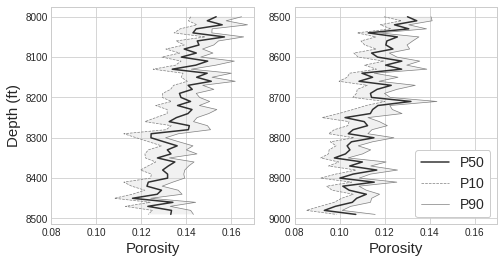

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(39)

depth = [i * 10 + 8000 for i in range(100)]
l = len(depth)
avg_por = []
p10_por = []
p90_por = []
for i, item in enumerate(depth):

    # You collect 12 rock core samples for each depth
    # Assume that sample porosity follows a normal distribution
    sample_size = 12
    por_samples = np.random.normal(loc=0.15 - i/2000, scale=0.022, size=sample_size)
    avg_por.append(np.mean(por_samples))

    # 80% confidence interval of mean
    p10, p90 = stats.t.interval(1 - 0.2, sample_size - 1, loc=np.mean(por_samples), scale=stats.sem(por_samples))
    p10_por.append(p10)
    p90_por.append(p90)

# plotting
plt.style.use('seaborn-whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(avg_por[:l//2], depth[:l//2], 'k', label='P50', alpha=0.8)
ax[0].plot(p10_por[:l//2], depth[:l//2], 'grey', linewidth=0.7, label='P10', linestyle='--')
ax[0].plot(p90_por[:l//2], depth[:l//2], 'grey', linewidth=0.7, label='P90')

ax[0].set_xlim(0.08, 0.17)
ax[0].set_ylabel('Depth (ft)', fontsize=15)
ax[0].set_xlabel('Porosity', fontsize=15)
ax[0].fill_betweenx(depth[:l//2], p10_por[:l//2], p90_por[:l//2], facecolor='lightgrey', alpha=0.3)
ax[0].invert_yaxis()

ax[1].plot(avg_por[l//2:], depth[l//2:], 'k', label='P50', alpha=0.8)
ax[1].plot(p10_por[l//2:], depth[l//2:], 'grey', linewidth=0.7, label='P10', linestyle='--')
ax[1].plot(p90_por[l//2:], depth[l//2:], 'grey', linewidth=0.7, label='P90')

ax[1].set_xlim(0.08, 0.17)
ax[1].set_xlabel('Porosity', fontsize=15)
ax[1].legend(loc='best', fontsize=14, framealpha=1, frameon=True)
ax[1].fill_betweenx(depth[l//2:], p10_por[l//2:], p90_por[l//2:], facecolor='lightgrey', alpha=0.3)
ax[1].invert_yaxis()

In [ ]:
import scipy.stats as st
import numpy as np
st.t.interval(0.8, 12 - 1, loc=14.5, scale= 4.3 / np.sqrt(12))

(12.807569748569543, 16.19243025143046)

In [ ]:
# Mr. White's

stats.t.interval(0.90, 21 - 1, loc=99.1, scale= 3 / np.sqrt(21))

(98.53702112341288, 99.6629788765871)

In [ ]:
# Mr. Pinkman's

st.t.interval(1 - 0.05, 18 - 1, loc=96.2, scale= 4 / np.sqrt(18))

(94.21084679714819, 98.18915320285181)

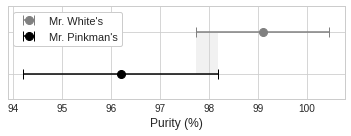

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

conf_pinkman = stats.t.interval(1 - 0.05, 18 - 1, loc=96.2, scale= 4 / np.sqrt(18))
conf_white = stats.t.interval(1 - 0.05, 21 - 1, loc=99.1, scale= 3 / np.sqrt(21))

plt.style.use('seaborn-whitegrid')
fig, ax = plt.subplots(figsize=(5, 2))

ax.errorbar(99.1, 1, xerr=(conf_white[1] - conf_white[0]) / 2,
            fmt='o', markersize=8, capsize=5, label='Mr. White\'s', color='grey')
ax.errorbar(96.2, 0, xerr=(conf_pinkman[1] - conf_pinkman[0]) / 2,
            fmt='o', markersize=8, capsize=5, label='Mr. Pinkman\'s', color='k')
ax.set_ylim(-0.6, 1.6)
ax.fill_betweenx([1, 0], conf_white[0], conf_pinkman[1], facecolor='lightgrey', alpha=0.3)
ax.legend(loc='best', fontsize=11, framealpha=1, frameon=True)
ax.set_xlabel('Purity (%)', fontsize=12)
ax.yaxis.set_major_formatter(plt.NullFormatter())
fig.tight_layout();

/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 7840 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 7840 missing from current font.
  font.set_text(s, 0, flags=flags)


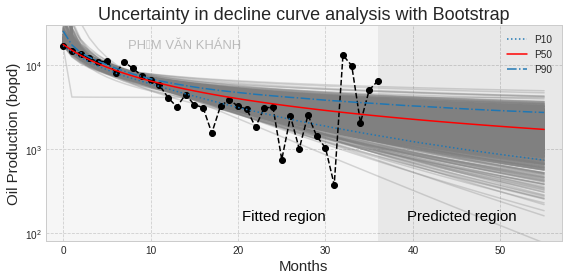

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

##################################### Prepare Data #########################################

file = 'https://aegis4048.github.io/downloads/notebooks/sample_data/decline_curve.xlsx'
df = pd.read_excel(file, sheet_name='sheet_1')
df = df[df['Oil Prod. (bopd)'] > 200]           # remove bad data points
t = df['Time'][1:].values[: -40]
y = df['Oil Prod. (bopd)'][1:].values[:-40]
x = np.array([i for i in range(len(t))])

#################################### Define function #######################################

def hyperbolic(x, qi, b, Di):
    return qi / (1 + b * Di * x) ** (1 / b)

################################# Bootstrap regression #####################################

np.random.seed(42)

y_boot_reg = []
for i in range(1000):

    # Bootstrapping
    boot_index = np.random.choice(range(0, len(y)), len(y))
    x_boot = x[boot_index]
    y_boot = y[boot_index]

    # Curve fit data
    popt, pcov = curve_fit(hyperbolic, x_boot, y_boot, maxfev=100000, p0=[max(y), 0.1, 0.1])

    # Define predicted region
    pred_x = [i for i in range(x[-1], x[-1] + 20)][1:]
    x_new = np.append(x, np.array([pred_x]))

    # Predict
    y_boot_reg = y_boot_reg + [hyperbolic(x_new, *popt)]

y_boot_reg = np.array(y_boot_reg)

p10 = np.percentile(y_boot_reg, 10, axis=0)
p50 = np.percentile(y_boot_reg, 50, axis=0)
p90 = np.percentile(y_boot_reg, 90, axis=0)

# Basic curve fit
popt, pcov = curve_fit(hyperbolic, x, y, maxfev=100000, p0=[max(y), 0.1, 0.1])

###################################### Plotting ##########################################

fig, ax = plt.subplots(figsize=(8, 4))

for reg_sample in y_boot_reg:
    ax.plot(x_new, reg_sample, color='grey', alpha=0.3)
ax.plot(x, y, '--o', color='k', alpha=1)
ax.plot(x_new, p10, ':',color='#1f77b4', alpha=1, label='P10')
ax.plot(x_new, hyperbolic(x_new, *popt), color='r', label='P50')
ax.plot(x_new, p90, '-.',color='#1f77b4', alpha=1, label='P90')

ax.set_yscale('log')
ax.set_ylim(80, 30000)
ax.set_xlim(-2, 57)
ax.set_xlabel('Months', fontsize=15)
ax.set_ylabel('Oil Production (bopd)', fontsize=15)
ax.set_title('Uncertainty in decline curve analysis with Bootstrap', fontsize=18)
ax.grid(True, linestyle='--', color='#acacac')

ax.axvspan(-2, x[-1], facecolor='#efefef', alpha=0.5)
ax.axvspan(x[-1], 57, facecolor='lightgrey', alpha=0.5)

ax.text(0.38, 0.1, 'Fitted region', fontsize=15,
        transform=ax.transAxes, color='k')
ax.text(0.7, 0.1, 'Predicted region', fontsize=15,
        transform=ax.transAxes, color='k')
ax.text(0.27, 0.91, 'PHẠM VĂN KHÁNH', fontsize=13, ha='center', va='center',
        transform=ax.transAxes, color='grey', alpha=0.5)
ax.legend()

fig.tight_layout()

In [ ]:
import pandas as pd
Gold=pd.read_csv('/content/Gold.csv')

In [ ]:
Gold

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-01-02,1302.300049,1317.599976,1302.300049,1313.699951,1313.699951,68.0
1,2018-01-03,1320.000000,1320.099976,1312.099976,1316.199951,1316.199951,42.0
2,2018-01-04,1319.400024,1322.000000,1319.400024,1319.400024,1319.400024,2.0
3,2018-01-05,1320.300049,1320.300049,1320.300049,1320.300049,1320.300049,1.0
4,2018-01-08,1319.900024,1319.900024,1314.599976,1318.599976,1318.599976,41.0
...,...,...,...,...,...,...,...
844,2021-05-11,1837.199951,1838.099976,1831.599976,1835.900024,1835.900024,420.0
845,2021-05-12,1825.199951,1825.199951,1821.699951,1822.599976,1822.599976,3.0
846,2021-05-13,1814.699951,1826.800049,1814.099976,1823.800049,1823.800049,100.0
847,2021-05-14,1824.500000,1842.900024,1824.500000,1837.900024,1837.900024,41.0


In [ ]:
Gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 849 entries, 0 to 848
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       849 non-null    object 
 1   Open       840 non-null    float64
 2   High       840 non-null    float64
 3   Low        840 non-null    float64
 4   Close      840 non-null    float64
 5   Adj Close  840 non-null    float64
 6   Volume     840 non-null    float64
dtypes: float64(6), object(1)
memory usage: 46.6+ KB


In [ ]:
Gold.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [ ]:
Gold.describe()

,Open,High,Low,Close,Adj Close,Volume
count,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000
mean,1513.096786,1520.237621,1505.822976,1513.050714,1513.050714,5993.984524
std,245.375801,248.728302,241.996313,245.462923,245.462923,34323.986254
min,1173.199951,1180.199951,1161.400024,1176.199951,1176.199951,0.000000
25%,1297.275024,1300.325012,1293.225006,1297.074982,1297.074982,33.000000
50%,1473.650024,1478.049988,1467.500000,1474.299988,1474.299988,154.500000
75%,1738.200043,1746.125030,1726.149994,1735.225006,1735.225006,538.250000
max,2045.500000,2063.000000,2040.000000,2051.500000,2051.500000,386334.000000


In [ ]:
loc_gold=Gold.Close.mean();scale_gold=Gold.Close.std();

In [ ]:
import scipy.stats as st
import numpy as np
st.t.interval(1 - 0.2, len(Gold) - 1, loc=loc_gold, scale= scale_gold/ np.sqrt(len(Gold)))

(1502.246166177489, 1523.8552617677508)

In [ ]:
# Tìm khoảng tin cậy 90% cho giá vàng lúc mở phiên
loc_gold=Gold.Open.mean();scale_gold=Gold.Open.std();
st.t.interval(1 - 0.2, len(Gold) - 1, loc=loc_gold, scale= scale_gold/ np.sqrt(len(Gold)))

(1502.296073115741, 1523.8974990366396)

In [ ]:
# Ước khoảng cho mở phiên cao hơn so với đóng phiên

In [ ]:
# Tìm khoảng ước lượng cho giá trị cao nhất
loc_gold=Gold.High.mean();scale_gold=Gold.High.std();
st.t.interval(1 - 0.2, len(Gold) - 1, loc=loc_gold, scale= scale_gold/ np.sqrt(len(Gold)))

(1509.2893408220214, 1531.185901016073)

In [ ]:
# Tìm khoảng ước lượng cho giá trị thấp nhất
loc_gold=Gold.Low.mean();scale_gold=Gold.Low.std();
st.t.interval(1 - 0.2, len(Gold) - 1, loc=loc_gold, scale= scale_gold/ np.sqrt(len(Gold)))

(1495.1710180220746, 1516.4749339469743)